<a href="https://colab.research.google.com/github/Coolguy4123/Data-Visualization-Project-2/blob/main/CS4990_ResumeVis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Preprocessing

In [ ]:
import pandas as pd

df = pd.read_csv("/content/Resume.csv", on_bad_lines='skip')

print(df.columns)
df.head()

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [ ]:
# --- Dropping columns "ID" & "Resume_html" ---
df.drop(columns=["ID", "Resume_html"], inplace=True)
df.head()

,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


# Text Preprocessing

In [ ]:
import nltk

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("punkt_tab") # For colab
# nltk.download("punkt") # For local runtime

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

stop_words = set(stopwords.words("english"))
lemmen = WordNetLemmatizer()
buzzwords = ["company", "name", "city", "state", "experience", "skill"]  # Resume buzzwords

def text_preprocessing(text: str) -> str:
  text = text.lower()                                                                   # Lower case the text
  text = re.sub(r"[^\w\s]", " ", text)                                                  # Remove punctuation
  text = word_tokenize(text)                                                            # Tokenize
  text = [word for word in text if word not in stop_words and word not in buzzwords]    # Remove stop words
  text = [word for word in text if word.isalpha() and len(word) > 2]                    # Remove numbers and short words
  text = [lemmen.lemmatize(word) for word in text]                                      # Lemmentize word (running -> run)
  return " ".join(text)


df["Resume_str"] = df["Resume_str"].apply(text_preprocessing)
df.head()


,Resume_str,Category
0,administrator marketing associate administrato...,HR
1,specialist operation summary versatile medium ...,HR
2,director summary year recruiting plus year hum...,HR
3,specialist summary dedicated driven dynamic ye...,HR
4,manager highlight skill department startup thr...,HR


In [ ]:
# df.to_csv("Preprocessed.csv")

# Text Feature Extraction

In [ ]:
# Term-Frequency
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X_counts = vectorizer.fit_transform(df["Resume_str"])


In [ ]:
# Get the list of unique words (features) learned by the vectorizer
feature_names = vectorizer.get_feature_names_out()
print(feature_names[:20])

['aa' 'aaa' 'aaae' 'aaahc' 'aaai' 'aac' 'aacc' 'aaccounting' 'aacn'
 'aacsb' 'aade' 'aaditya' 'aadt' 'aafes' 'aafet' 'aagi' 'aaham' 'aai'
 'aakash' 'aalto']


In [ ]:
import pandas as pd

# Each column represents a word, each row represents a resume
tf_df = pd.DataFrame(X_counts.toarray(), columns=feature_names)
tf_df.head()

,aa,aaa,aaae,aaahc,aaai,aac,aacc,aaccounting,aacn,aacsb,...,zzxzx,µpg,çatalhöyük,école,ética,étiquette,éxito,òwaterfalló,últimos,ﬁlm
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
import numpy as np

word_counts = X_counts.toarray().sum(axis=0) # Sum word counts across all documents

tf_summary = pd.DataFrame({
    "word": feature_names,
    "frequency": word_counts
}).sort_values(by="frequency", ascending=False)

tf_summary.head(10)

,word,frequency
17795,management,12179
7331,customer,11345
26765,service,9070
26010,sale,8553
4160,business,8089
23445,project,7887
27338,skill,7729
29153,system,7256
29424,team,7117
5575,client,6503


In [ ]:
doc_idx = 3
doc_counts = tf_df.iloc[doc_idx]

top_words = doc_counts.sort_values(ascending=False).head(10)
print(top_words)

client        7
customer      7
call          6
management    6
service       5
team          5
microsoft     5
inquiry       4
resolution    4
maintained    4
Name: 3, dtype: int64


# Visualization

In [ ]:
# Install wordcloud library
!pip install wordcloud

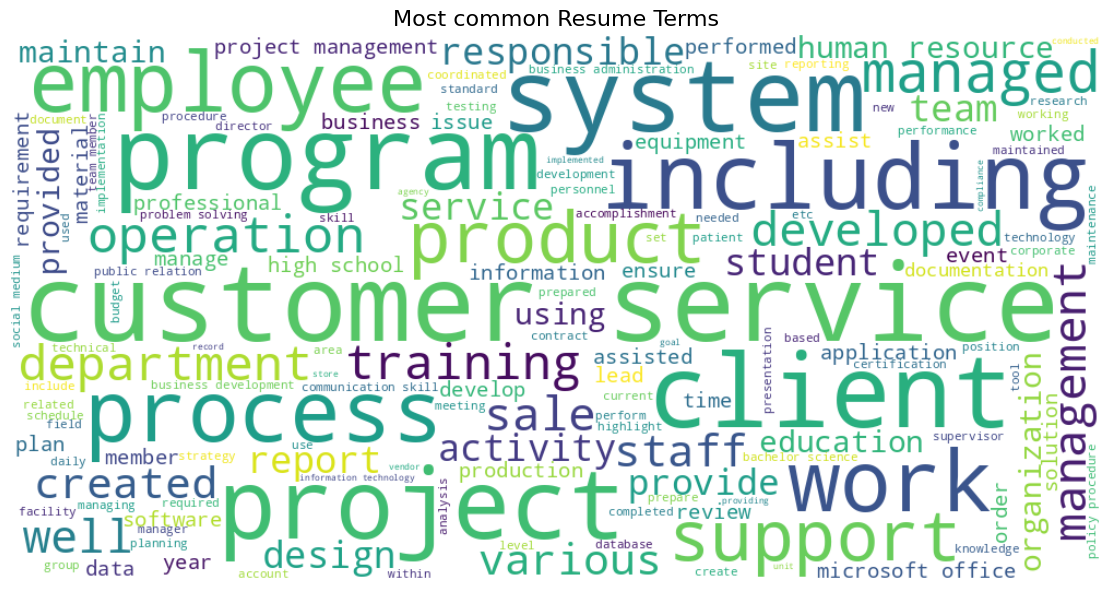

In [ ]:
# Word cloud showing the most frequent terms across all resumes

import matplotlib.pyplot as plt
from wordcloud import WordCloud

all_text = " ".join(df["Resume_str"])

wordcloud = WordCloud(width=1000, height=500, background_color="white",
                      max_words=150, colormap="viridis").generate(all_text)

plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most common Resume Terms", fontsize=16)
plt.tight_layout()
plt.show()

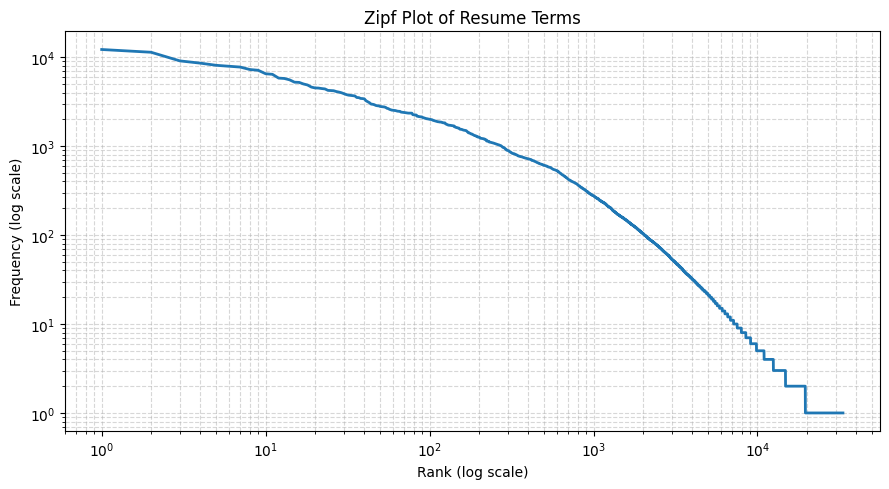

In [ ]:
#Zipf plot showing the rank-frequency distribution of resume terms

import numpy as np

freqs = tf_summary["frequency"].values
ranks = np.arange(1, len(freqs) + 1)

plt.figure(figsize=(9, 5))
plt.loglog(ranks, freqs, linewidth=2)
plt.xlabel("Rank (log scale)")
plt.ylabel("Frequency (log scale)")
plt.title("Zipf Plot of Resume Terms")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

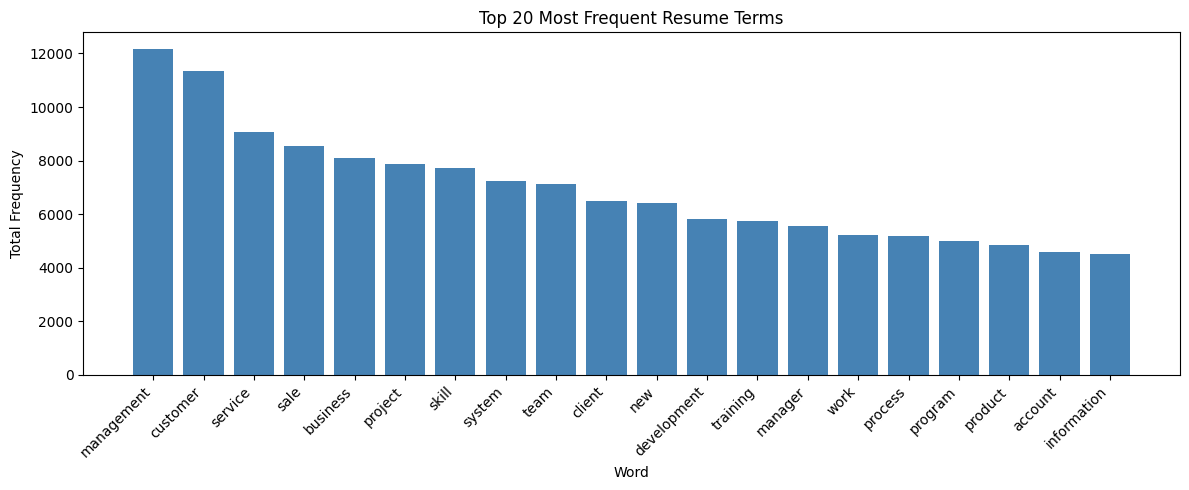

In [ ]:
# Bar chart of the top 20 most frequent terms across all resumes

top20 = tf_summary.head(20)

plt.figure(figsize=(12, 5))
plt.bar(top20["word"], top20["frequency"], color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Word")
plt.ylabel("Total Frequency")
plt.title("Top 20 Most Frequent Resume Terms")
plt.tight_layout()
plt.show()

In [ ]:
# Interactive word cloud by category

import ipywidgets as widgets
from wordcloud import WordCloud
import matplotlib.pyplot as plt

category_options = ["All"] + sorted(df["Category"].unique().tolist())

dropdown = widgets.Dropdown(options=category_options, description="Category:")

def update_wordcloud(category):
  if category == "All":
    filtered_text = " ".join(df["Resume_str"])
  else:
    filtered_text = " ".join(df.loc[df["Category"] == category, "Resume_str"])

  wc = WordCloud(width=1000, height=500, background_color="white",
              max_words=150, colormap="viridis").generate(filtered_text)

  plt.figure(figsize=(14, 6))
  plt.imshow(wc, interpolation="bilinear")
  plt.axis("off")
  plt.title(f"Most Common Terms - {category}", fontsize=16)
  plt.tight_layout()
  plt.show()

widgets.interactive(update_wordcloud, category=dropdown)

interactive(children=(Dropdown(description='Category:', options=('All', 'ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE…

# Interactive Development

In [ ]:
# TODO